In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math


normaldist = np.random.normal
lognormaldist = np.random.lognormal

class VA:
    def __init__(self):
        self.eps = 0.0001
        self.dT = 1/100
        self.maxT = 10
        self.nVectLength = int(self.maxT/self.dT + self.eps)
        self.nPerYear = int(1./self.dT + self.eps)
        self.dEquityDrift = 0.07 # eta
        self.dEquityVola = 0.20 # sigma
        self.start = time.time()
        
    def vGenerateTrajectory(self,mu,sigma):
        return(normaldist(mu,sigma,self.nVectLength))
    
    def vGenerateLNTrajectory(self,mu,sigma):
        return(lognormaldist(mu,sigma,self.nVectLength))
    
    def vGenerateShareReturnTrajectory(self):
        return(lognormaldist((self.dEquityDrift- a.dEquityVola**2/2.)/self.nPerYear,self.dEquityVola/(self.nPerYear)**0.5,self.nVectLength))
    
    def vCalcCululativeSharePrince(self,dReturnVect):
        a =[1.]
        for i in dReturnVect:
            a.append(a[-1]*i)
        return(a)
    
    def NextInterationBrownianBridge(self,Vector,sigma=0.2):
        dt = 1./(len(Vector)-1)/2.
        print(dt)
        st = sigma * dt**.5
        for i in range(len(Vector)-1):
            value = 0.5*(Vector[2*i]+Vector[2*i+1]) + normaldist(0,st)
            Vector=np.insert(Vector,2*i+1,value)
        return(Vector)
    
    def vResetTime(self):
        self.start = time.time()
        
    def vPrintTime(self):
        self.end = time.time()
        print("Elapsed time:  %.2f"%(self.end - self.start))
        

class BSOption:

    def __init__(self):
        import math
        try:
# Try whether we have scipy library to use the function - otherwise do it yourself 
            import scipy.stats 
            self.normcdfgen = scipy.stats.norm.cdf
        except:
            print ("use own normdist cdf")
            
            def erfcc(self,x):
                z = abs(x)
                t = 1. / (1. + 0.5*z)
                r = t * math.exp(-z*z-1.26551223+t*(1.00002368+t*(.37409196+
                  t*(.09678418+t*(-.18628806+t*(.27886807+
                  t*(-1.13520398+t*(1.48851587+t*(-.82215223+
                  t*.17087277)))))))))
                
                if (x >= 0.):
                    return (r)
                else:
                    return (2. - r)


            def normcdfgen(self, x, mu=0, sigma=1):
                t = x-mu;
                y = 0.5*self.erfcc(-t/(sigma*math.sqrt(2.0)));
                if y>1.0:
                    y = 1.0;
                return y
            
            
    def normcdf(self, x):
        return(self.normcdfgen(x))    
    
    def BlackScholesEuro(self,Price, CallPut, AssetP, Strike, RiskFree, DividendY, Time, Volatility):

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%  BlackScholesEuro(Price, CallPut, AssetP, Strike, RiskFree, DividendY, Time, Volatility):
#% Computes the Black-Scholes European Call/Put Option Values based
#% on the following inputs:
#% CallPut           =       Call = 1, Put = 0
#% AssetP            =       Underlying Asset Price
#% Strike            =       Strike Price of Option
#% RiskFree          =       Risk Free rate of interest
#% Time              =       Time to Maturity
#% Volatility        =       Volatility of the Underlying
#% Please note that the use of this code is not restricted in anyway.
#% However, referencing the author of the code would be appreciated.
#% To run this program, simply use the function defined in the 1st line.
#% http://www.global-derivatives.com
#% info@global-derivatives.com
#% Kevin Cheng (Nov 2003)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

        dt = Volatility * (Time) ** 0.5
        df = RiskFree - DividendY + 0.5 * Volatility ** 2           # Computes the drift term
        d1 = (math.log(AssetP / Strike) + df * Time) / dt                #Calculates the d1 term used in Black-Scholes
        d2 = d1 - dt                                                # Calculates the d2 term used in Black-Scholes
        alpha = math.exp(-DividendY * Time)
# The cumulative normal distribution functions for use in computing calls
        nd1 = self.normcdf(d1)
        nd2 = self.normcdf(d2)
# The cumulative normal distribution functions for use in computing puts
        nnd1 = self.normcdf(-d1)
        nnd2 = self.normcdf(-d2)

        if CallPut == 1:
    # Computes call price
            Price = AssetP * alpha * nd1 - Strike * math.exp(-RiskFree * Time) * nd2
        else:
  # Computes put price
            Price = Strike * math.exp(-RiskFree * Time) * nnd2 - AssetP * alpha * nnd1
        return([Price, CallPut, AssetP, Strike, RiskFree, DividendY, Time, Volatility])


#function [] = BlackScholesMertonEuro(AssetP, Strike, RiskFree, DividendY, Time, Volatility)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#% Computes the Black-Scholes-Merton European Call/Put Option Values based
#% on the following inputs:
#% AssetP            =       Underlying Asset Price
#% Strike            =       Strike Price of Option
#% RiskFree          =       Risk Free rate of interest
#% DividendY         =       Dividend Yield of Underlying
#% Time              =       Time to Maturity
#% Volatility        =       Volatility of the Underlying
#% Please note that the use of this code is not restricted in anyway.
#% However, referencing the author of the code would be appreciated.
#% To run this program, simply use the function defined in the 1st line.
#% http://www.global-derivatives.com
#% info@global-derivatives.com
#% Kevin Cheng (Nov 2003)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

#$dt = Volatility * \sqrt{Time}$;
#$df = RiskFree - DividendY + 0.5 * Volatility ^ 2$;            % Computes the drift term
#$d1 = (\log( AssetP / Strike) + df * Time ) / dt$;             % Calculates the d1 term used in Black-Scholes
#$d2 = d1 - dt$;                                                % Calculates the d2 term used in Black-Scholes

#% The cumulative normal distribution functions for use in computing calls
#nd1 = normcdf(d1);
#nd2 = normcdf(d2);
#% The cumulative normal distribution functions for use in computing puts
#nnd1 = normcdf(-d1);
#nnd2 = normcdf(-d2);

#% Computes call price
#CallPrice = AssetP * Exp(-DividendY * Time) * nd1 - Strike * Exp(-RiskFree * Time) * nd2
#% Computes put price
#PutPrice = Strike * Exp(-RiskFree * Time) * nnd2 - AssetP * Exp(-DividendY * Time) * nnd1#


    def Greeks(self,Delta, Gamma, Theta, Rho1, Rho2, Vega, CallPut, AssetP, Strike, RiskFree, DividendY, Time, Volatility):
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#% Computes the Black-Scholes-Merton European Call/Put Greeks based
#% on the following inputs:
#% CallPut           =       For a call, the input is "1". Puts, use "0".
#% AssetP            =       Underlying Asset Price
#% Strike            =       Strike Price of Option
#% RiskFree          =       Risk Free rate of interest
#% DividendY         =       Dividend Yield of Underlying
#% Time              =       Time to Maturity
#% Volatility        =       Volatility of the Underlying
#% Please note that the use of this code is not restricted in anyway.
#% However, referencing to the global derivatives website would be appreciated.
#% To run this program, simply use the function defined in the 1st line.
#% http://www.global-derivatives.com
#% info@global-derivatives.com
#% Kevin Cheng (Nov 2003)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

        Pi = 3.141592653589
        dt = Volatility * (Time) ** 0.5
        df = RiskFree - DividendY + 0.5 * Volatility ** 2                       # Computes the drift term
        d1 = (math.log(AssetP / Strike) + df * Time) / dt                # Calculates the d1 term used in Black-Scholes
        d2 = d1 - dt                                                # Calculates the d2 term used in Black-Scholes

# The cumulative normal distribution functions for use in computing calls
        nd1 = self.normcdf(d1)
        nd2 = self.normcdf(d2)
# The cumulative normal distribution functions for use in computing puts
        nnd1 = self.normcdf(-d1)
        nnd2 = self.normcdf(-d2)
        nn1 = (1 / (2 * Pi) ** 0.5 * math.exp(-0.5 * d1 ** 2))

# Computes call greeks
        if CallPut == 1:
            Delta = nd1 * math.exp(-DividendY * Time)
            Gamma = (nn1 * math.exp(-DividendY * Time)) / (AssetP * dt)
            Theta = -((AssetP * nn1 * math.exp(-DividendY * Time) * Volatility) / 2 * (Time) ** 0.5) + (-DividendY * AssetP * nd1 * math.exp(-DividendY * Time)) - (RiskFree * Strike * math.exp(-RiskFree * Time) * nd2)
            Vega = AssetP * (Time) ** 0.5 * nn1 * math.exp(-DividendY * Time)
            Rho1 = Strike * Time * math.exp(-RiskFree * Time) * nd2
            Rho2 = -AssetP * math.exp(-DividendY * Time) * Time * nd1
        else:
# Computes put greeks
            Delta = (nd1 - 1) * math.exp(-DividendY * Time)
            Gamma = (nn1 * math.exp(-DividendY * Time)) / (AssetP * dt)
            Theta = -((AssetP * nn1 * Volatility * math.exp(-DividendY * Time)) / 2 * (Time) ** 0.5) - (DividendY * AssetP * nnd1 * math.exp(-DividendY * Time)) + (RiskFree * Strike * math.exp(-RiskFree * Time) * nnd2)
            Vega = AssetP * (Time) ** 0.5 * nn1 * math.exp(-DividendY * Time)
            Rho1 = -Strike * Time * math.exp(-RiskFree * Time) * nnd2
            Rho2 = AssetP * math.exp(-DividendY * Time) * Time * nnd1

        return([Delta, Gamma, Theta, Rho1, Rho2, Vega, CallPut, AssetP, Strike, RiskFree, DividendY, Time, Volatility])


cc = BSOption()

print(cc.BlackScholesEuro(0, 0, 1000., 700., 0.02, 0.01 , 1., 0.2))
print(cc.BlackScholesEuro(0, 0, 1000., 700., 0.02, 0.01 , 0.01, 0.2))
print(cc.BlackScholesEuro(0, 0, 600., 700., 0.02, 0.01 , 1., 0.2))
print(cc.BlackScholesEuro(0, 0, 600., 700., 0.02, 0.01 , 0.01, 0.2))



[np.float64(2.1543489727060923), 0, 1000.0, 700.0, 0.02, 0.01, 1.0, 0.2]
[np.float64(1.6475276882259898e-71), 0, 1000.0, 700.0, 0.02, 0.01, 0.01, 0.2]
[np.float64(109.66995857680615), 0, 600.0, 700.0, 0.02, 0.01, 1.0, 0.2]
[np.float64(99.92001099916672), 0, 600.0, 700.0, 0.02, 0.01, 0.01, 0.2]


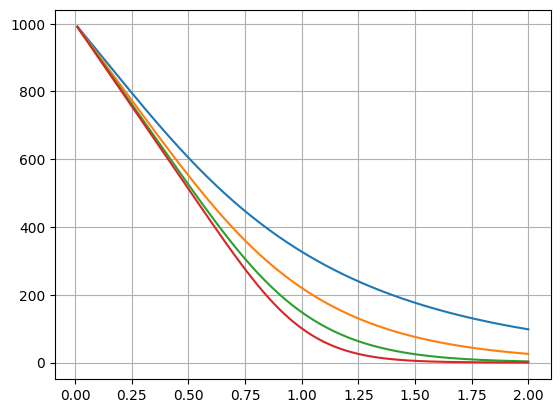

In [4]:
x=[]
y=[]
y1=[]
y2=[]
y3=[]

for i in range(1,201):
    x.append(0.01*i)
    z = cc.BlackScholesEuro(0, 1, 1000., 1000*x[-1], 0.02, 0.00 , 10., 0.2)
    y.append(z[0])
    z = cc.BlackScholesEuro(0, 1, 1000., 1000*x[-1], 0.02, 0.00 , 5., 0.2)
    y1.append(z[0])
    z = cc.BlackScholesEuro(0, 1, 1000., 1000*x[-1], 0.02, 0.00 , 2.5, 0.2)
    y2.append(z[0])
    z = cc.BlackScholesEuro(0, 1, 1000., 1000*x[-1], 0.02, 0.00 , 1.25, 0.2)
    y3.append(z[0])
    
plt.plot(x,y,x,y1,x,y2,x,y3)
plt.grid(True)


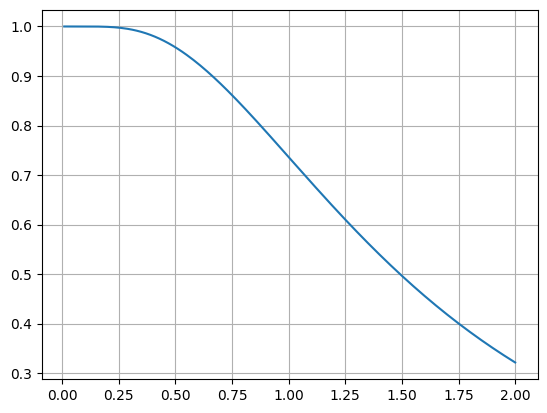

In [5]:
delta =[]
for level in x:
    greeks = cc.Greeks(0,0,0,0,0, 0, 1, 1000., 1000*level, 0.02, 0.00 , 10., 0.2)
    delta.append(greeks[0])
    
plt.plot(x,delta)
plt.grid(True)

In [6]:
TradingGrid = "%10s | %10s | %10s | %10s | %10s \n" %("Equity L", "Price", "Delta", "Gamma", "Rho")
NewLine = "%10.3f | %10.1f | %10.4f | %10.6f | %10.1f \n" 
AllLevels = [0.1,0.3,0.5,0.7,0.9,1.0,1.1,1.3,1.5,1.7,1.9]
for level in AllLevels:
    z = cc.BlackScholesEuro(0, 1, 1000., 1000*level, 0.02, 0.00 , 10., 0.2)
    price = z[0]
    greeks = cc.Greeks(0,0,0,0,0, 0, 1, 1000., 1000*level, 0.02, 0.00 , 10., 0.2)
    delta = greeks[0]
    gamma = greeks[1]
    rho = greeks[3]
    TradingGrid += NewLine % (level, price, delta, gamma, rho)
print(TradingGrid)

  Equity L |      Price |      Delta |      Gamma |        Rho 
     0.100 |      918.1 |     1.0000 |   0.000000 |      818.6 
     0.300 |      755.8 |     0.9944 |   0.000025 |     2386.2 
     0.500 |      604.6 |     0.9580 |   0.000142 |     3534.7 
     0.700 |      475.3 |     0.8842 |   0.000308 |     4089.8 
     0.900 |      370.7 |     0.7879 |   0.000458 |     4171.7 
     1.000 |      327.1 |     0.7365 |   0.000516 |     4093.7 
     1.100 |      288.6 |     0.6850 |   0.000562 |     3963.6 
     1.300 |      225.2 |     0.5861 |   0.000616 |     3609.5 
     1.500 |      176.4 |     0.4966 |   0.000631 |     3202.0 
     1.700 |      138.8 |     0.4182 |   0.000617 |     2793.9 
     1.900 |      109.8 |     0.3511 |   0.000586 |     2412.5 



0.5
0.25
0.125
0.0625
0.03125
0.015625
Elapsed time:  0.01
MartingaleTest
Sim: 10
Sim: 50
Sim: 100
Sim: 500
Sim: 1000
Sim: 5000
Elapsed time:  0.83
Sim: 1000
Elapsed time:  0.94
Sim: 5000
Elapsed time:  1.53
0.5
0.25
0.125
0.0625
0.03125
0.015625
0.0078125
0.00390625
0.001953125
0.0009765625


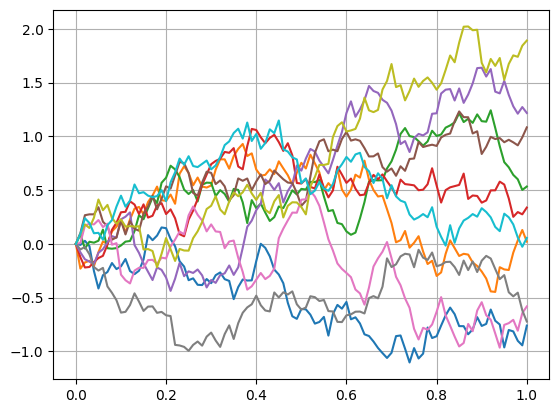

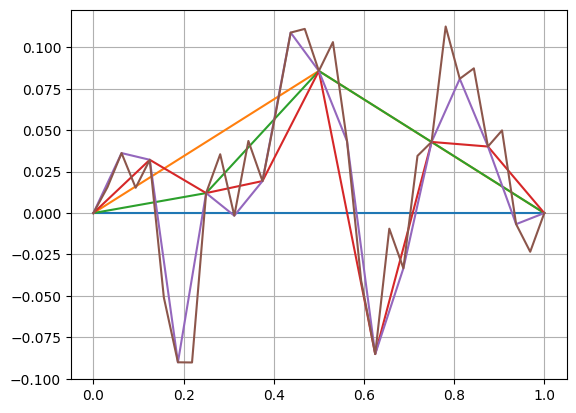

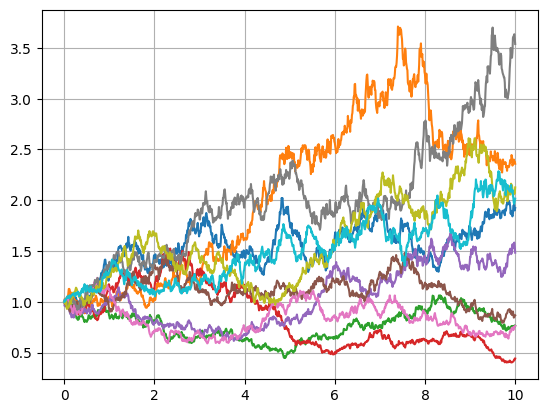

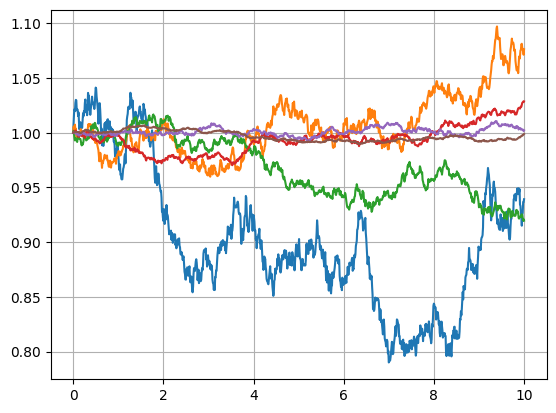

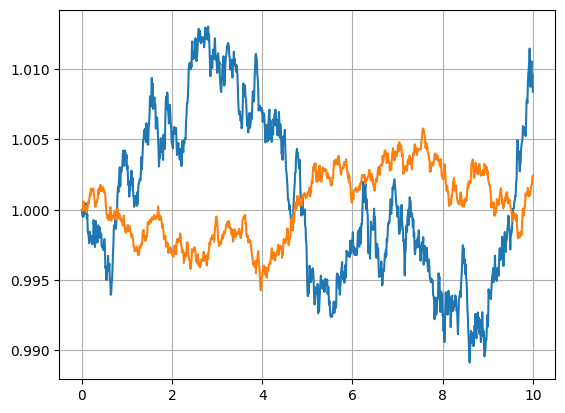

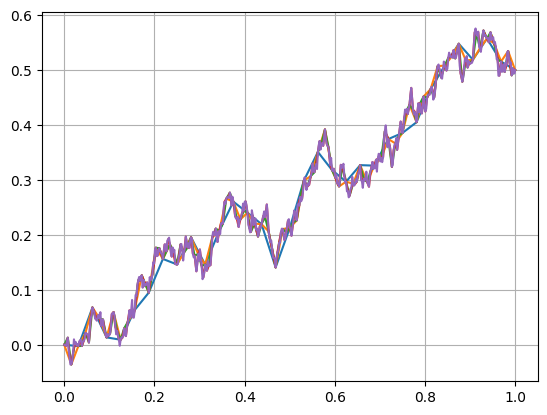

In [7]:
n= 100
a= VA()
plt.figure(1)
for i in range(10):
    a.nVectLength = n
    b= a.vGenerateTrajectory(0,1/n**.5)
    c= [0]
    for i in range(len(b)):
        c.append(c[-1]+b[i])
    plt.plot(np.array(range(len(c)))*1./n,c)

plt.grid(True)


plt.figure(2)
Vector = np.array([0.,0.])
for i in range(6):
    x = np.array(range(len(Vector))) /(len(Vector)-1.)
    plt.plot(x,Vector)
    Vector = a.NextInterationBrownianBridge(Vector)

plt.grid(True)   

plt.figure(3)
a= VA()
for i in range(10):
    b= a.vGenerateShareReturnTrajectory()
    c= a.vCalcCululativeSharePrince(b)
    plt.plot(np.array(range(len(c)))*a.dT,c)

plt.grid(True)

a.vPrintTime()

print("MartingaleTest")

a.dEquityDrift = 0 
J = [10,50,100,500,1000,5000]
x = np.array(range(len(c)))*a.dT
plt.figure(4)

for i in J:
    print("Sim:",i)
    y = x * 0.
    for j in range(i):
        b= a.vGenerateShareReturnTrajectory()
        c= a.vCalcCululativeSharePrince(b)
        y +=c
    y /= i
    plt.plot(x,y)

plt.grid(True)

a.vPrintTime()

a.dEquityDrift = 0
J = [1000,5000]
x = np.array(range(len(c)))*a.dT
plt.figure(5)

for i in J:
    print("Sim:",i)
    y = x * 0.
    for j in range(i):
        b= a.vGenerateShareReturnTrajectory()
        c= a.vCalcCululativeSharePrince(b)
        y +=c
    y /= i
    a.vPrintTime()
    plt.plot(x,y)

plt.grid(True)

plt.figure(6)
Vector = np.array([0.,0.5])
for i in range(10):
    x = np.array(range(len(Vector))) /(len(Vector)-1.)
    if i>4:
        plt.plot(x,Vector)
    Vector = a.NextInterationBrownianBridge(Vector)

plt.grid(True)